In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
ML_SMALL_PATH = "../dataset/ml-latest-small"

In [5]:
movie_df = pd.read_csv(ML_SMALL_PATH + "/movies.csv")
movie_df.shape

(9742, 3)

In [6]:
movie_df.head(5)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
movie_df['movieId'].unique()

array([     1,      2,      3, ..., 193585, 193587, 193609], shape=(9742,))

In [8]:
rating_df = pd.read_csv(ML_SMALL_PATH+"/ratings.csv")
rating_df.shape

(100836, 4)

In [9]:
rating_df.head(5)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [10]:
tags_df = pd.read_csv(ML_SMALL_PATH+"/tags.csv")
tags_df.shape

(3683, 4)

In [11]:
tags_df.head(5)

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [12]:
tags_df['tag'].unique

<bound method Series.unique of 0                  funny
1        Highly quotable
2           will ferrell
3           Boxing story
4                    MMA
              ...       
3678           for katie
3679             austere
3680              gun fu
3681    heroic bloodshed
3682    Heroic Bloodshed
Name: tag, Length: 3683, dtype: str>

In [13]:
link_df = pd.read_csv(ML_SMALL_PATH+"/links.csv")
link_df.shape

(9742, 3)

In [14]:
link_df.head(5)  # imdbld is id used in imdb and tmdbId is id used in tmdb

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


## made sure there is no nan entry

In [15]:
movie_df.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [16]:
rating_df.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [17]:
tags_df.isnull().sum()

userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

In [18]:
link_df.isnull().sum()

movieId    0
imdbId     0
tmdbId     8
dtype: int64

## 8 movies is not offered in tmdb, but I won't insert any values for them since this won't be used for recommendation but for look up in different movie site

In [31]:
missing_link_df = link_df.loc[link_df['tmdbId'].isna()]
missing_link_df

,movieId,imdbId,tmdbId
624,791,113610,NaN
843,1107,102336,NaN
2141,2851,81454,NaN
3027,4051,56600,NaN
5532,26587,92337,NaN
5854,32600,377059,NaN
6059,40697,105946,NaN
7382,79299,874957,NaN


## Summary of rate
it is 0.5 to 5.0 out of 5, and mean and median is 3.5. seems distributed in bell curve.
Since distribution above is wegihted by count of rate, so it accounts more for heavy user. The distribution of mean rating grouped by user showed that most people rate movies around 3.3 to 4.0 on average, but some rates quite low.

In [19]:
rating_df.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [67]:
print(rating_df['userId'].nunique())
print(rating_df['movieId'].nunique())

610
9724


In [20]:
rating_df.median()

userId       3.250000e+02
movieId      2.991000e+03
rating       3.500000e+00
timestamp    1.186087e+09
dtype: float64

In [21]:
rating = rating_df["rating"]

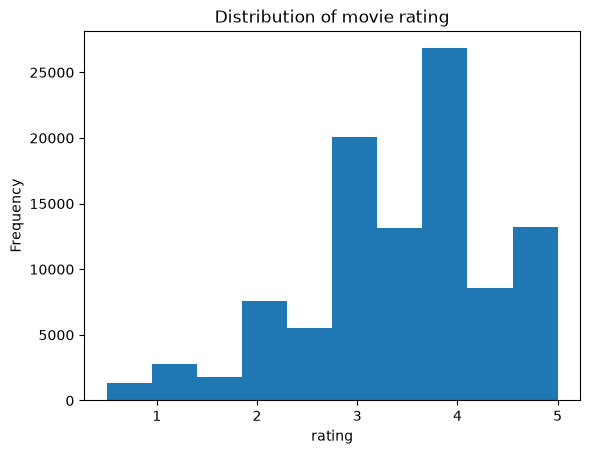

In [22]:
plt.hist(rating, bins=10)
plt.title('Distribution of movie rating')
plt.xlabel("rating")
plt.ylabel("Frequency")
plt.show()

In [41]:
# get rating average difference between user
ratingavg_by_userid=rating_df.groupby('userId')['rating'].agg(
    number_of_ratings='count',
    mean_rating='mean',
    rating_std='std'
)
ratingavg_by_userid.head()

,number_of_ratings,mean_rating,rating_std
userId,,,
1,232,4.366379,0.800048
2,29,3.948276,0.805615
3,39,2.435897,2.090642
4,216,3.555556,1.314204
5,44,3.636364,0.990441


In [ ]:
low_ratings=ratingavg_by_userid.sort_values('mean_rating').head(10)
low_ratings

In [57]:
high_ratings=ratingavg_by_userid.sort_values('mean_rating', ascending=False).head(10)
high_ratings

,number_of_ratings,mean_rating,rating_std
userId,,,
53,20,5.000000,0.000000
251,23,4.869565,0.526942
515,26,4.846154,0.339683
25,26,4.807692,0.376216
30,34,4.735294,0.553711
523,75,4.693333,0.449424
348,55,4.672727,0.432672
171,82,4.634146,0.598603
452,202,4.556931,0.605100


In [59]:
low_high_ratings = pd.concat([high_ratings, low_ratings])
low_high_ratings.to_csv('../reports/tables/low_high_rating_users.csv')


In [46]:
ratingavg_by_userid.median()

number_of_ratings    70.500000
mean_rating           3.694385
rating_std            0.902378
dtype: float64

In [55]:
ratingavg_by_userid.describe().to_csv('../reports/tables/summary_of_user_mean.csv', index=True)

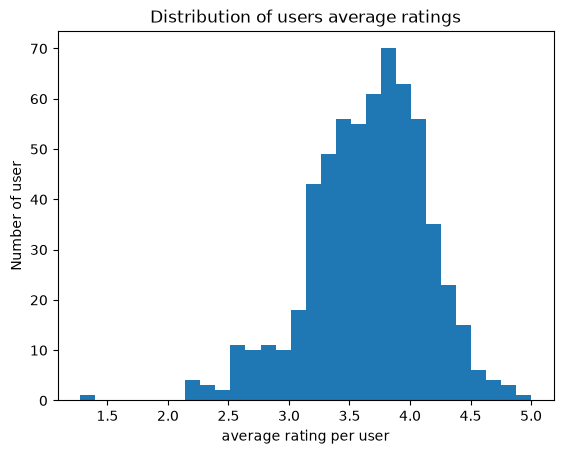

In [45]:
plt.hist(ratingavg_by_userid['mean_rating'], bins=30)
plt.xlabel('average rating per user')
plt.ylabel('Number of user')
plt.title('Distribution of users average ratings')
plt.show()

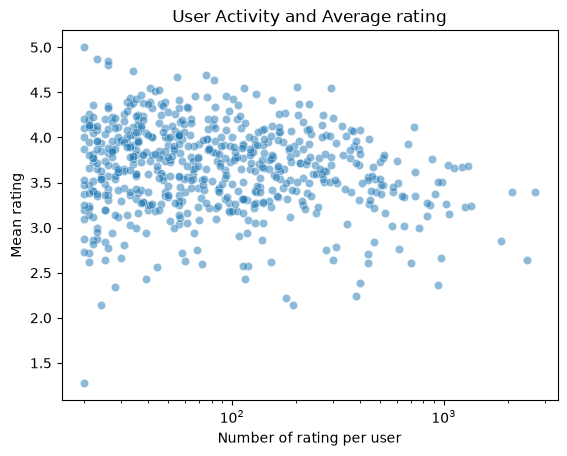

In [51]:
sns.scatterplot(data=ratingavg_by_userid,
                x='number_of_ratings',
                y='mean_rating',
                alpha=0.5)
plt.xscale('log')
plt.xlabel('Number of rating per user')
plt.ylabel('Mean rating')
plt.title('User Activity and Average rating')
plt.show()

In [52]:
correlation = ratingavg_by_userid[
    ["number_of_ratings", "mean_rating"]
].corr(method="spearman")

correlation

,number_of_ratings,mean_rating
number_of_ratings,1.000000,-0.135426
mean_rating,-0.135426,1.000000


# Summary of genere

In [23]:
genres = movie_df['genres']

In [24]:
genres

0       Adventure|Animation|Children|Comedy|Fantasy
1                        Adventure|Children|Fantasy
2                                    Comedy|Romance
3                              Comedy|Drama|Romance
4                                            Comedy
                           ...                     
9737                Action|Animation|Comedy|Fantasy
9738                       Animation|Comedy|Fantasy
9739                                          Drama
9740                               Action|Animation
9741                                         Comedy
Name: genres, Length: 9742, dtype: str

In [25]:
genres.unique()

<StringArray>
['Adventure|Animation|Children|Comedy|Fantasy',
                  'Adventure|Children|Fantasy',
                              'Comedy|Romance',
                        'Comedy|Drama|Romance',
                                      'Comedy',
                       'Action|Crime|Thriller',
                          'Adventure|Children',
                                      'Action',
                   'Action|Adventure|Thriller',
                               'Comedy|Horror',
 ...
    'Action|Adventure|Fantasy|Horror|Thriller',
                           'Comedy|Sci-Fi|War',
             'Comedy|Mystery|Romance|Thriller',
               'Fantasy|Horror|Sci-Fi|Western',
                       'Animation|Crime|Drama',
           'Adventure|Mystery|Sci-Fi|Thriller',
                  'Action|Comedy|Crime|Horror',
            'Action|Adventure|Children|Sci-Fi',
      'Action|Adventure|Comedy|Fantasy|Sci-Fi',
             'Action|Animation|Comedy|Fantasy']
Length: 951, dtype: s